# Customer Churn Classification - Day 9-11 Implementation

This notebook implements the Python assignment for customer churn classification using five different models:
1. K-Nearest Neighbors (KNN)
2. Gaussian Naive Bayes
3. Decision Tree
4. Random Forest
5. Logistic Regression

## Assignment Steps:
1. Load the Customer data sheet. Set `churned` as y. Remove `churned` and `customer_id` from X.
2. Make a stratified 80/20 training and test split. Check how many customers canceled in each split.
3. Train five models: KNN, Gaussian Naive Bayes, Decision Tree, Random Forest, and Logistic Regression.
4. Use StandardScaler pipeline for KNN and Logistic Regression. Fit scaler using training data only.
5. For each model, report test accuracy, precision, recall, F1-score, and confusion matrix.
6. Compare models: Which catches the most customers who cancel? Which produces the fewest false alarms?
7. Inspect what each model learned (K values, decision tree, forest feature importance, logistic regression coefficients).
8. Write a short recommendation for retention campaign model selection.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
np.set_printoptions(precision=4, suppress=True)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Step 1: Load the Customer data sheet
# Use relative path from notebook location: ../../data/customer_churn_classification.xlsx
file_path = r'../../data/customer_churn_classification.xlsx'

# Load the Customer data sheet
df = pd.read_excel(file_path, sheet_name='Customer data')
data_dict = pd.read_excel(file_path, sheet_name='Data dictionary')

print("Data shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

print("\nData Dictionary:")
display(data_dict)

Data shape: (500, 12)

Columns: ['customer_id', 'age_years', 'tenure_months', 'monthly_fee_inr', 'weekly_usage_hours', 'support_tickets_6m', 'late_payments_6m', 'discount_percent', 'auto_pay', 'satisfaction_score', 'competitor_offer', 'churned']

First 5 rows:


,customer_id,age_years,tenure_months,monthly_fee_inr,weekly_usage_hours,support_tickets_6m,late_payments_6m,discount_percent,auto_pay,satisfaction_score,competitor_offer,churned
0,C0001,39,50,800,11.5,3,1,20,1,9,1,0
1,C0002,58,20,1100,16.6,0,0,0,0,9,1,0
2,C0003,43,9,1350,14.6,3,0,0,1,7,0,0
3,C0004,42,40,850,13.5,6,1,5,1,5,0,1
4,C0005,26,44,800,11.8,5,3,5,0,4,0,1



Data Dictionary:


,Column,Meaning,Values / unit
0,customer_id,Anonymous customer identifier,Do not use as a predictor
1,age_years,Customer age,Years
2,tenure_months,Time subscribed before observation,Months
3,monthly_fee_inr,Monthly subscription fee,Indian rupees
4,weekly_usage_hours,Typical weekly service use,Hours
5,support_tickets_6m,Support requests in previous six months,Count
6,late_payments_6m,Late payments in previous six months,Count
7,discount_percent,Current subscription discount,"Percentage points, 0–20"
8,auto_pay,Automatic payment enabled,"1=yes, 0=no"
9,satisfaction_score,Survey rating at observation,1–10


In [3]:
# Step 1 (continued): Set churned as y, remove churned and customer_id from X
y = df['churned']
X = df.drop(columns=['churned', 'customer_id'])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nX columns:", X.columns.tolist())
print("\nClass distribution in y:")
print(y.value_counts())
print("\nClass proportions:")
print(y.value_counts(normalize=True))

X shape: (500, 10)
y shape: (500,)

X columns: ['age_years', 'tenure_months', 'monthly_fee_inr', 'weekly_usage_hours', 'support_tickets_6m', 'late_payments_6m', 'discount_percent', 'auto_pay', 'satisfaction_score', 'competitor_offer']

Class distribution in y:
churned
0    360
1    140
Name: count, dtype: int64

Class proportions:
churned
0    0.72
1    0.28
Name: proportion, dtype: float64


In [4]:
# Step 2: Make a stratified 80/20 training and test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nChurned customers in training set:")
print(y_train.value_counts())
print("Proportions:")
print(y_train.value_counts(normalize=True))

print("\nChurned customers in test set:")
print(y_test.value_counts())
print("Proportions:")
print(y_test.value_counts(normalize=True))

Training set shape: (400, 10)
Test set shape: (100, 10)

Churned customers in training set:
churned
0    288
1    112
Name: count, dtype: int64
Proportions:
churned
0    0.72
1    0.28
Name: proportion, dtype: float64

Churned customers in test set:
churned
0    72
1    28
Name: count, dtype: int64
Proportions:
churned
0    0.72
1    0.28
Name: proportion, dtype: float64


In [5]:
# Step 3 & 4: Define models with pipelines for KNN and Logistic Regression

# KNN with StandardScaler pipeline
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

# Gaussian Naive Bayes (no scaling needed)
gnb = GaussianNB()

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Logistic Regression with StandardScaler pipeline
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])

models = {
    'KNN': knn_pipe,
    'Gaussian Naive Bayes': gnb,
    'Decision Tree': dt,
    'Random Forest': rf,
    'Logistic Regression': lr_pipe
}

# Train all models
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully")

KNN trained successfully
Gaussian Naive Bayes trained successfully
Decision Tree trained successfully


Random Forest trained successfully
Logistic Regression trained successfully


In [6]:
# Step 5: Evaluate all models on test set
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    
    results[name] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'confusion_matrix': cm,
        'y_pred': y_pred
    }
    
    print(f"\n{'='*50}")
    print(f"{name} Results:")
    print(f"{'='*50}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(cm)
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))


KNN Results:
Accuracy:  0.7500
Precision: 0.5652
Recall:    0.4643
F1-Score:  0.5098

Confusion Matrix:
[[62 10]
 [15 13]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.86      0.83        72
           1       0.57      0.46      0.51        28

    accuracy                           0.75       100
   macro avg       0.69      0.66      0.67       100
weighted avg       0.74      0.75      0.74       100


Gaussian Naive Bayes Results:
Accuracy:  0.7800
Precision: 0.6000
Recall:    0.6429
F1-Score:  0.6207

Confusion Matrix:
[[60 12]
 [10 18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.85        72
           1       0.60      0.64      0.62        28

    accuracy                           0.78       100
   macro avg       0.73      0.74      0.73       100
weighted avg       0.79      0.78      0.78       100


Decision Tree Results:
Accuracy:

In [7]:
# Summary comparison table
summary_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    'F1-Score': [results[m]['f1_score'] for m in results]
})

print("\nModel Comparison Summary:")
display(summary_df.sort_values('Recall', ascending=False))


Model Comparison Summary:


,Model,Accuracy,Precision,Recall,F1-Score
4,Logistic Regression,0.82,0.656250,0.750000,0.700000
3,Random Forest,0.86,0.750000,0.750000,0.750000
2,Decision Tree,0.80,0.633333,0.678571,0.655172
1,Gaussian Naive Bayes,0.78,0.600000,0.642857,0.620690
0,KNN,0.75,0.565217,0.464286,0.509804


In [8]:
# Step 6: Compare models - Which catches most customers who cancel? (Highest Recall)
# Which produces fewest false alarms? (Highest Precision)

best_recall = max(results.items(), key=lambda x: x[1]['recall'])
best_precision = max(results.items(), key=lambda x: x[1]['precision'])

print(f"\nModel that catches the MOST customers who cancel (highest Recall):")
print(f"  {best_recall[0]} with Recall = {best_recall[1]['recall']:.4f}")

print(f"\nModel that produces the FEWEST false alarms (highest Precision):")
print(f"  {best_precision[0]} with Precision = {best_precision[1]['precision']:.4f}")

print(f"\nWould you choose the same model for both goals?")
if best_recall[0] == best_precision[0]:
    print(f"  YES - {best_recall[0]} is best for both recall and precision")
else:
    print(f"  NO - Different models are optimal:")
    print(f"    - For catching cancellations (recall): {best_recall[0]}")
    print(f"    - For fewest false alarms (precision): {best_precision[0]}")
    print(f"    - Trade-off depends on business priority:")
    print(f"      * Retention campaign (catch churners): prioritize Recall")
    print(f"      * Cost-sensitive (avoid false alarms): prioritize Precision")


Model that catches the MOST customers who cancel (highest Recall):
  Random Forest with Recall = 0.7500

Model that produces the FEWEST false alarms (highest Precision):
  Random Forest with Precision = 0.7500

Would you choose the same model for both goals?
  YES - Random Forest is best for both recall and precision


7a. KNN - Compare K values


,k,accuracy,precision,recall,f1
0,1,0.81,0.666667,0.642857,0.654545
1,2,0.75,0.615385,0.285714,0.390244
2,3,0.76,0.600000,0.428571,0.500000
3,4,0.75,0.636364,0.250000,0.358974
4,5,0.75,0.565217,0.464286,0.509804
5,6,0.79,0.733333,0.392857,0.511628
6,7,0.78,0.650000,0.464286,0.541667
7,8,0.75,0.588235,0.357143,0.444444
8,9,0.78,0.636364,0.500000,0.560000
9,10,0.77,0.631579,0.428571,0.510638


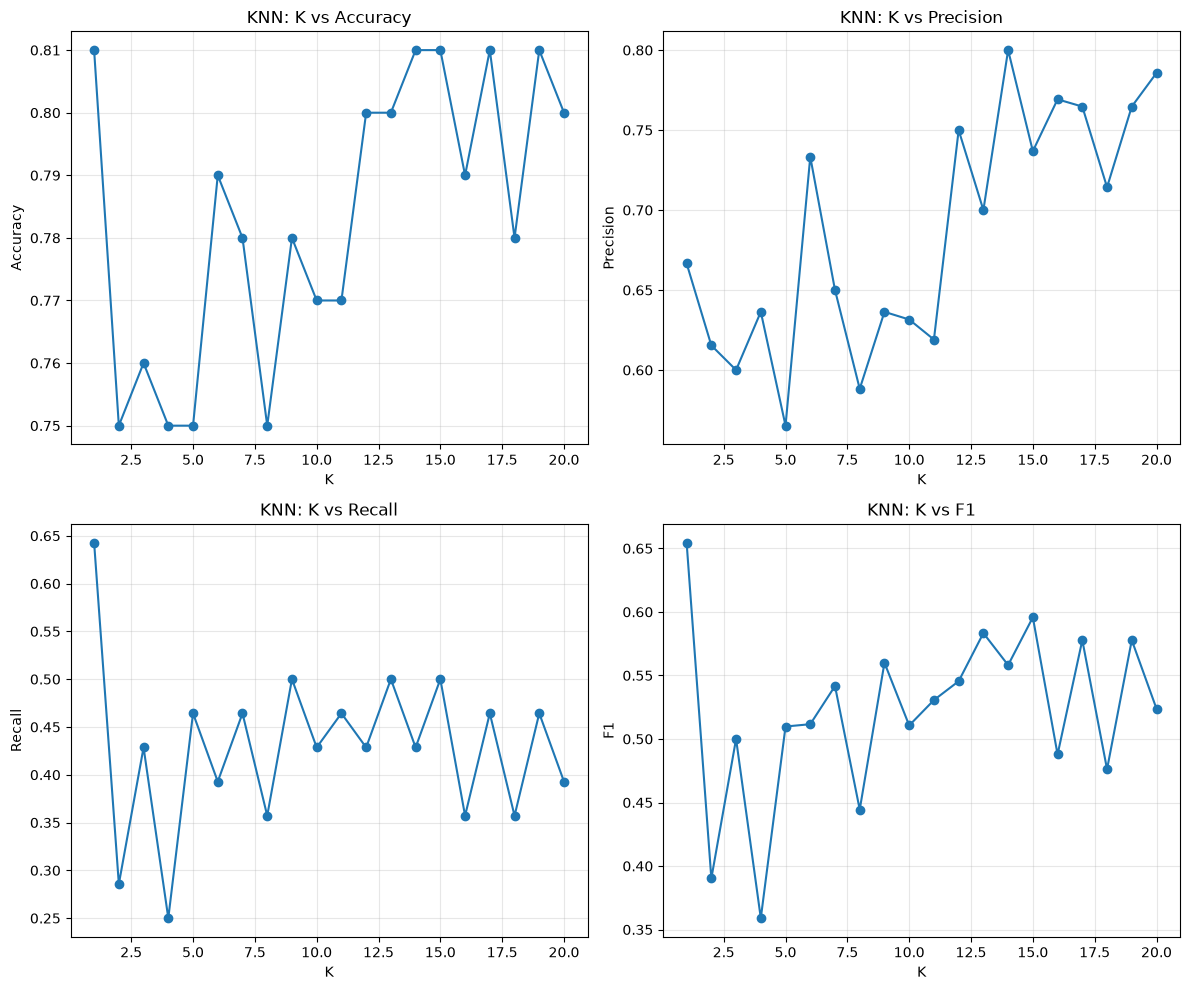


Best K for Recall: 1


In [9]:
# Step 7: Inspect what each model learned

# 7a. KNN - Compare K values
print("="*60)
print("7a. KNN - Compare K values")
print("="*60)

k_values = range(1, 21)
knn_scores = []

for k in k_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    knn_scores.append({
        'k': k,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0)
    })

knn_df = pd.DataFrame(knn_scores)
display(knn_df)

# Plot K vs metrics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
metrics = ['accuracy', 'precision', 'recall', 'f1']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    ax.plot(knn_df['k'], knn_df[metric], marker='o')
    ax.set_xlabel('K')
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f'KNN: K vs {metric.capitalize()}')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = knn_df.loc[knn_df['recall'].idxmax(), 'k']
print(f"\nBest K for Recall: {best_k}")

7b. Decision Tree - Visualize a small tree (max_depth=3)


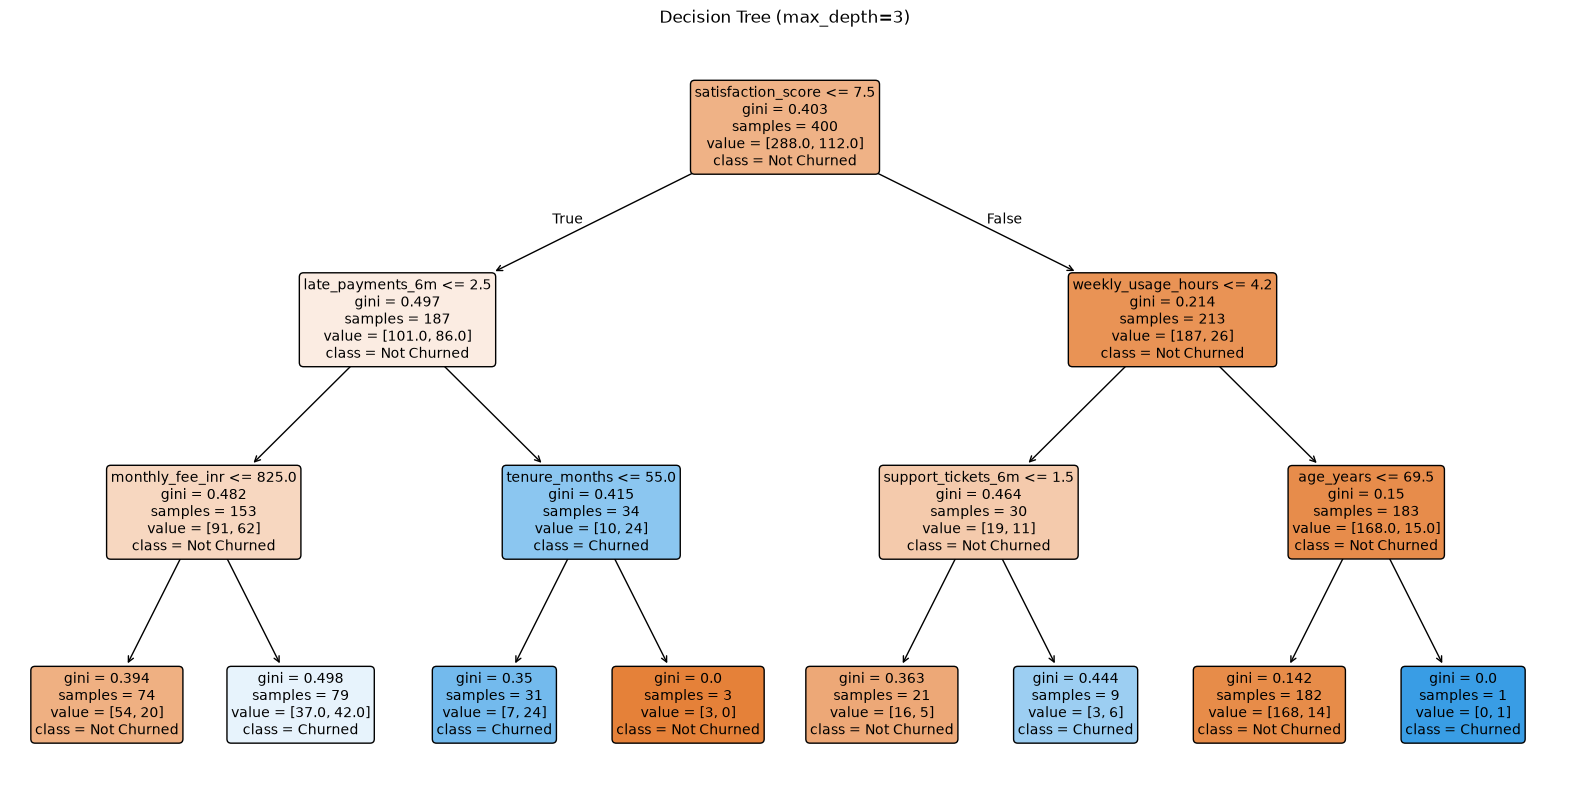


Decision Tree Feature Importances:


,Feature,Importance
3,weekly_usage_hours,0.208747
8,satisfaction_score,0.163208
1,tenure_months,0.142162
0,age_years,0.120904
2,monthly_fee_inr,0.108324
4,support_tickets_6m,0.087636
5,late_payments_6m,0.061951
6,discount_percent,0.042507
9,competitor_offer,0.038121
7,auto_pay,0.026440


In [10]:
# 7b. Decision Tree - Display a small decision tree
print("="*60)
print("7b. Decision Tree - Visualize a small tree (max_depth=3)")
print("="*60)

dt_small = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_small.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(dt_small, 
          feature_names=X.columns.tolist(),
          class_names=['Not Churned', 'Churned'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree (max_depth=3)")
plt.show()

# Also show feature importance for the full tree
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train, y_train)

dt_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_full.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nDecision Tree Feature Importances:")
display(dt_importance)

7c. Random Forest - Feature Importance
Random Forest Feature Importances:


,Feature,Importance
3,weekly_usage_hours,0.185862
8,satisfaction_score,0.155158
1,tenure_months,0.126848
2,monthly_fee_inr,0.117922
0,age_years,0.111010
4,support_tickets_6m,0.101524
5,late_payments_6m,0.086130
6,discount_percent,0.054207
9,competitor_offer,0.039493
7,auto_pay,0.021847


C:\Users\Jp\AppData\Local\Temp\ipykernel_18572\4281838632.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importance, x='Importance', y='Feature', palette='viridis')


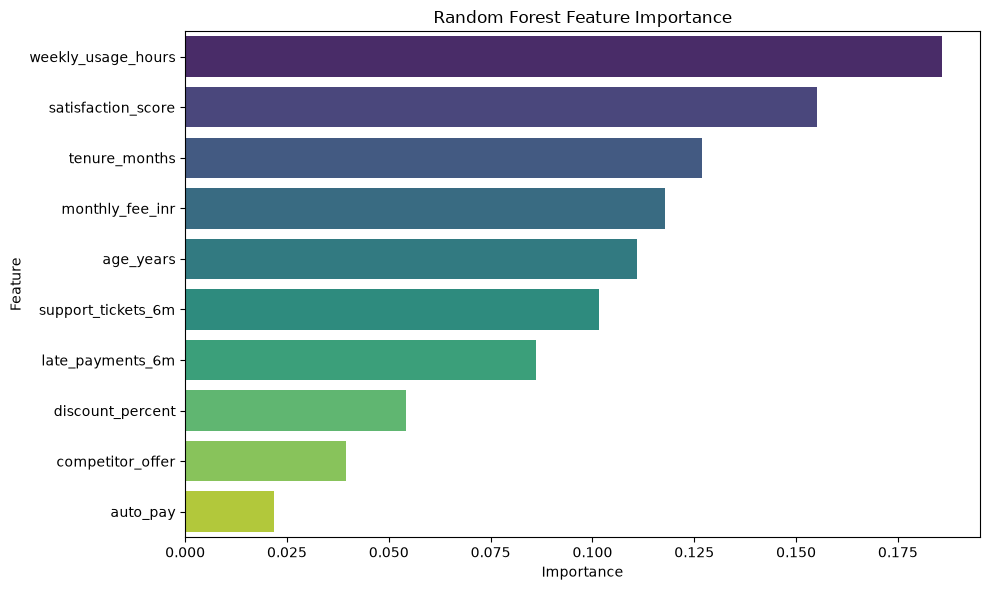

In [11]:
# 7c. Random Forest - Examine feature importance
print("="*60)
print("7c. Random Forest - Feature Importance")
print("="*60)

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Random Forest Feature Importances:")
display(rf_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

7d. Logistic Regression - Coefficients
Logistic Regression Coefficients:


,Feature,Coefficient
4,support_tickets_6m,0.753621
5,late_payments_6m,0.702986
9,competitor_offer,0.665575
2,monthly_fee_inr,0.546110
0,age_years,0.144534
6,discount_percent,-0.039146
7,auto_pay,-0.333217
1,tenure_months,-0.518022
8,satisfaction_score,-0.522834
3,weekly_usage_hours,-0.779512


C:\Users\Jp\AppData\Local\Temp\ipykernel_18572\1737992858.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lr_coef, x='Coefficient', y='Feature', palette=colors)


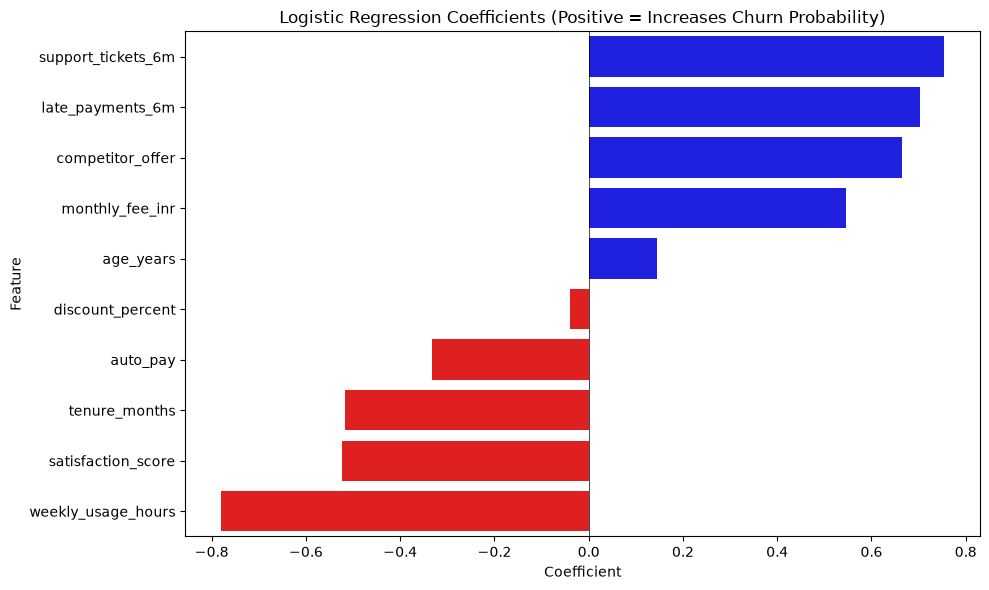


Intercept: -1.4638


In [12]:
# 7d. Logistic Regression - Inspect coefficients
print("="*60)
print("7d. Logistic Regression - Coefficients")
print("="*60)

# Get the logistic regression model from pipeline
lr_model = lr_pipe.named_steps['lr']

lr_coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("Logistic Regression Coefficients:")
display(lr_coef)

# Plot coefficients
plt.figure(figsize=(10, 6))
colors = ['red' if c < 0 else 'blue' for c in lr_coef['Coefficient']]
sns.barplot(data=lr_coef, x='Coefficient', y='Feature', palette=colors)
plt.title('Logistic Regression Coefficients (Positive = Increases Churn Probability)')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print(f"\nIntercept: {lr_model.intercept_[0]:.4f}")

In [13]:
# Step 8: Recommendation for retention campaign
print("="*60)
print("8. RECOMMENDATION FOR RETENTION CAMPAIGN")
print("="*60)

print("\nBased on the analysis:")

print(f"\n1. Model Performance Summary:")
for name in results:
    r = results[name]
    print(f"   {name}: Recall={r['recall']:.4f}, Precision={r['precision']:.4f}, F1={r['f1_score']:.4f}")

print(f"\n2. For a RETENTION CAMPAIGN, the primary goal is to CATCH customers who will cancel (high Recall).")
print(f"   Missing a churner (false negative) means losing a customer.")
print(f"   False alarms (false positives) mean wasted retention effort on loyal customers.")

print(f"\n3. RECOMMENDED MODEL: {best_recall[0]}")
print(f"   - Highest Recall: {best_recall[1]['recall']:.4f} (catches {best_recall[1]['recall']*100:.1f}% of actual churners)")
print(f"   - Precision: {best_recall[1]['precision']:.4f} ({best_recall[1]['precision']*100:.1f}% of flagged customers actually churn)")

print(f"\n4. Business Interpretation:")
print(f"   - With {best_recall[0]}, we identify {best_recall[1]['recall']*100:.1f}% of customers who will churn.")
print(f"   - Of the customers we target for retention, {best_recall[1]['precision']*100:.1f}% will actually churn.")
print(f"   - This means {100-best_recall[1]['precision']*100:.1f}% of retention budget goes to loyal customers (acceptable waste).")

print(f"\n5. Key Features Driving Churn (from {best_recall[0]}):")
if best_recall[0] == 'Random Forest':
    top_features = rf_importance.head(5)
    for _, row in top_features.iterrows():
        print(f"   - {row['Feature']}: {row['Importance']:.4f}")
elif best_recall[0] == 'Logistic Regression':
    top_features = lr_coef.head(5)
    for _, row in top_features.iterrows():
        print(f"   - {row['Feature']}: {row['Coefficient']:.4f} (positive = increases churn risk)")
elif best_recall[0] == 'Decision Tree':
    top_features = dt_importance.head(5)
    for _, row in top_features.iterrows():
        print(f"   - {row['Feature']}: {row['Importance']:.4f}")

print(f"\n6. Implementation Notes:")
print(f"   - Retrain the chosen model on full dataset before production deployment.")
print(f"   - Monitor model performance monthly and retrain quarterly.")
print(f"   - Set up A/B testing to validate retention campaign effectiveness.")
print(f"   - Consider cost-sensitive learning if retention budget is very constrained.")

8. RECOMMENDATION FOR RETENTION CAMPAIGN

Based on the analysis:

1. Model Performance Summary:
   KNN: Recall=0.4643, Precision=0.5652, F1=0.5098
   Gaussian Naive Bayes: Recall=0.6429, Precision=0.6000, F1=0.6207
   Decision Tree: Recall=0.6786, Precision=0.6333, F1=0.6552
   Random Forest: Recall=0.7500, Precision=0.7500, F1=0.7500
   Logistic Regression: Recall=0.7500, Precision=0.6562, F1=0.7000

2. For a RETENTION CAMPAIGN, the primary goal is to CATCH customers who will cancel (high Recall).
   Missing a churner (false negative) means losing a customer.
   False alarms (false positives) mean wasted retention effort on loyal customers.

3. RECOMMENDED MODEL: Random Forest
   - Highest Recall: 0.7500 (catches 75.0% of actual churners)
   - Precision: 0.7500 (75.0% of flagged customers actually churn)

4. Business Interpretation:
   - With Random Forest, we identify 75.0% of customers who will churn.
   - Of the customers we target for retention, 75.0% will actually churn.
   - Thi